# 데이터 이해

In [51]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
df = sns.load_dataset("titanic")
df.shape

(891, 15)

In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [54]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [55]:
#결측치 확인
# df.isnull() => 결측치 유무
# df.isnull().sum() => 각 컬럼별 결측치 수
# df.isnull().sum().sort_values(ascending=False) => 결측치가 높은 컬럼이 위로 조회
# df.isnull().sum() / len(df) => 전체 데이터에 대한 결측치 비율
# (df.isnull().sum() / len(df)).round(4) => 소수점 4자리까지 반올림...
((df.isnull().sum() / len(df)).round(4)).sort_values(ascending=False)

deck           0.7722
age            0.1987
embarked       0.0022
embark_town    0.0022
sex            0.0000
pclass         0.0000
survived       0.0000
fare           0.0000
parch          0.0000
sibsp          0.0000
class          0.0000
adult_male     0.0000
who            0.0000
alive          0.0000
alone          0.0000
dtype: float64

# EDA 데이터
## 수치형 데이터

### 컬럼정보
1. survived: 생존 여부(0: 사망, 1: 생존)
2. pclass: 객실등급(1: 1등급, 2: 2등급, 3: 3등급)
3. sex: 성별(male: 남자, female: 여자)
4. age: 나이
5. sibsp: 함께 탑승한 형제 및 배우자 수
6. parch: 함께 탑승한 자녀 및 부모 수
7. fare: 요금
8. embarked: 탑승지(C: Cherbourg, Q: Queenstown, S: Southampton)
9. class: 객실 등급(First: 1등급, Second: 2등급, Third: 3등급)
10. who: man(남자), woman(여자), child(아이)
11. adult_male: 성인 남자인지 여부(True: 성인남자, False: 그외)
12. deck: 선실번호 첫 알파벳
13. embark_town: 탑승지(Cherbourg, Queenstown, Southampton)
14. alive: 생존여부(no: 사망, yes: 생존)
15. alone: 혼자 탑승했는지 여부(True: 혼자 탑승, False: 가족과 탑승)

- survived : 범주형 > 명목형 데이터
- pclass   : 범주형 > 순서형 데이터
- age      : 수치형 > 이산형 데이터  
- sibsp    : 수치형 > 이산형 데이터
- parch    : 수치형 > 이산형 데이터
- fare     : 수치형 > 연속형 데이터

In [56]:

#프로그램 적으로 수치형 데이터
# => 진짜 수치형 데이터는 아직 아님
df_number = df.select_dtypes(include=np.number)

df_number.shape

(891, 6)

In [57]:
df_number.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   age       714 non-null    float64
 3   sibsp     891 non-null    int64  
 4   parch     891 non-null    int64  
 5   fare      891 non-null    float64
dtypes: float64(2), int64(4)
memory usage: 41.9 KB


# 범주형 데이터

- sex          : 범주형
- embarked     : 범주형
- who          : 범주형
- class        : 범주형           
- embark_town  : 범주형
- alive        : 범주형
- adult_male   : 범주형
- deck         : 범주형
- embark_town  : 범주형
- alone        : 범주형

In [58]:
df_str = df.select_dtypes(exclude = np.number)

df_str.shape

(891, 9)

In [59]:
df_str.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   sex          891 non-null    str     
 1   embarked     889 non-null    str     
 2   class        891 non-null    category
 3   who          891 non-null    str     
 4   adult_male   891 non-null    bool    
 5   deck         203 non-null    category
 6   embark_town  889 non-null    str     
 7   alive        891 non-null    str     
 8   alone        891 non-null    bool    
dtypes: bool(2), category(2), str(5)
memory usage: 38.9 KB


In [60]:
df_str.head()

,sex,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,male,S,Third,man,True,NaN,Southampton,no,False
1,female,C,First,woman,False,C,Cherbourg,yes,False
2,female,S,Third,woman,False,NaN,Southampton,yes,True
3,female,S,First,woman,False,C,Southampton,yes,False
4,male,S,Third,man,True,NaN,Southampton,no,True


In [61]:
col_str.extend(list(df_str.columns))

col_str

['survived',
 'pclass',
 'sex',
 'embarked',
 'class',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alive',
 'alone',
 'sex',
 'embarked',
 'class',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alive',
 'alone']

# 수치형 데이터 EDA 분석

In [62]:
df_number = df[col_number]

df_number.head()

,survived,age,sibsp,parch,fare
0,0,22.0,1,0,7.2500
1,1,38.0,1,0,71.2833
2,1,26.0,0,0,7.9250
3,1,35.0,1,0,53.1000
4,0,35.0,0,0,8.0500


In [63]:
df_number.describe()

,survived,age,sibsp,parch,fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,29.699118,0.523008,0.381594,32.204208
std,0.486592,14.526497,1.102743,0.806057,49.693429
min,0.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,80.000000,8.000000,6.000000,512.329200


In [64]:
# 위 정보를 사용해서 타겟 값을 survived로 해서 각각의 상관관계를 보려면 어떻게 해야할까
# survived 변수와의 상관계수를 내림차순으로 정렬하여 확인
corr_survived = df_number.corr()['survived'].sort_values(ascending=False)
corr_survived


survived    1.000000
fare        0.257307
parch       0.081629
sibsp      -0.035322
age        -0.077221
Name: survived, dtype: float64

In [65]:
# 평균 분산 표준편차
df_number.groupby(['survived'])['age'].agg(['mean','var','std'])

,mean,var,std
survived,,,
0,30.626179,200.848698,14.172110
1,28.343690,223.530965,14.950952


### 첨도 분석
- 3보다 크면, 날카롭다
- 3보다 작으면, 넓다.
- 3과 비슷한 경우에는 정규분포와 비슷

In [66]:
df_number['age'].kurt()

np.float64(0.17827415364210353)

<Axes: xlabel='age', ylabel='Count'>

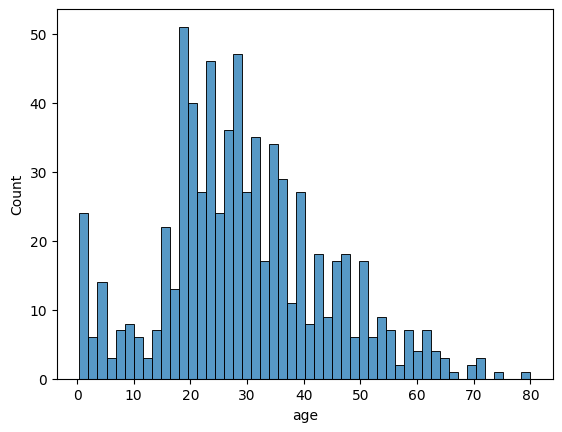

In [67]:
sns.histplot(
    data=df_number, 
    x="age",
    bins = 50
)

In [68]:
df_number['fare'].kurt()


np.float64(33.39814088089868)

<Axes: xlabel='fare', ylabel='Count'>

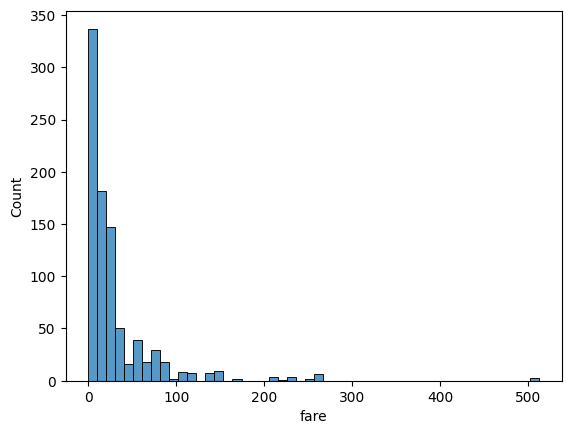

In [69]:
sns.histplot(
    data=df_number, 
    x="fare",
    bins = 50
)

In [70]:
df_number['age_log'] = np.log1p(df_number["age"])

In [71]:
df_number[["age", "age_log"]].head()

,age,age_log
0,22.0,3.135494
1,38.0,3.663562
2,26.0,3.295837
3,35.0,3.583519
4,35.0,3.583519


In [72]:
df_number['age_log'].kurt()

np.float64(4.380083950865307)

<Axes: xlabel='age_log', ylabel='Count'>

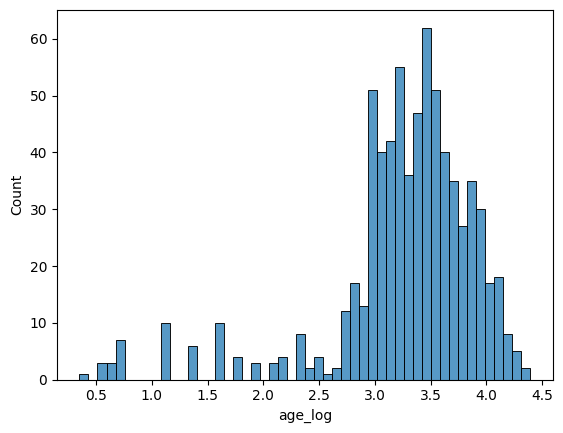

In [73]:
sns.histplot(
    data=df_number, 
    x="age_log",
    bins = 50
)

In [74]:
df_number['fare_log'] = np.log1p(df_number["fare"])

<Axes: xlabel='fare_log', ylabel='Count'>

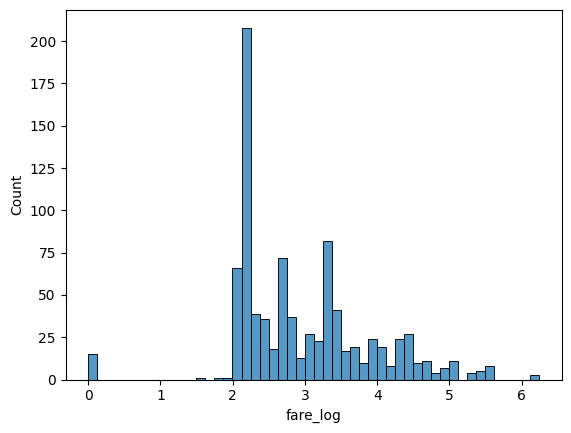

In [75]:
sns.histplot(
    data=df_number, 
    x="fare_log",
    bins = 50
)

- 외도나 첨도의 해석은 로그 밖에 답이 없다.

### 왜도 분석
> 일반적인 경우
- -0.5~0.5 : 상당히 대칭
- -1.0~-0.5 또는 0.5~1.0 : 적당히 치우침
- -1.0 이하 또는 1.0 이사 : 매우 치우침



In [76]:
df_number["fare"].skew()

np.float64(4.787316519674893)

In [77]:
df_number["fare_log"].skew()

np.float64(0.3949280095189306)

In [78]:
df_number["age"].skew()

np.float64(0.38910778230082704)

In [79]:
df_number["age_log"].skew()

np.float64(-1.8774882259647618)

# 범주형 EDA 분석

In [80]:
df_str = df[col_str]

df_str.head()

,survived,pclass,sex,embarked,class,who,adult_male,deck,embark_town,alive,alone,sex,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,S,Third,man,True,NaN,Southampton,no,False,male,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,C,First,woman,False,C,Cherbourg,yes,False,female,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,S,Third,woman,False,NaN,Southampton,yes,True,female,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,S,First,woman,False,C,Southampton,yes,False,female,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,S,Third,man,True,NaN,Southampton,no,True,male,S,Third,man,True,NaN,Southampton,no,True


In [82]:
df_str.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   embarked     889 non-null    str     
 4   class        891 non-null    category
 5   who          891 non-null    str     
 6   adult_male   891 non-null    bool    
 7   deck         203 non-null    category
 8   embark_town  889 non-null    str     
 9   alive        891 non-null    str     
 10  alone        891 non-null    bool    
 11  sex          891 non-null    str     
 12  embarked     889 non-null    str     
 13  class        891 non-null    category
 14  who          891 non-null    str     
 15  adult_male   891 non-null    bool    
 16  deck         203 non-null    category
 17  embark_town  889 non-null    str     
 18  alive        891 non-null    str     
 19

In [85]:
df_str['survived'] = df_str['survived'].astype('category')
df_str['pclass'] = df_str['pclass'].astype('category')

df_str.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    category
 1   pclass       891 non-null    category
 2   sex          891 non-null    str     
 3   embarked     889 non-null    str     
 4   class        891 non-null    category
 5   who          891 non-null    str     
 6   adult_male   891 non-null    bool    
 7   deck         203 non-null    category
 8   embark_town  889 non-null    str     
 9   alive        891 non-null    str     
 10  alone        891 non-null    bool    
 11  sex          891 non-null    str     
 12  embarked     889 non-null    str     
 13  class        891 non-null    category
 14  who          891 non-null    str     
 15  adult_male   891 non-null    bool    
 16  deck         203 non-null    category
 17  embark_town  889 non-null    str     
 18  alive        891 non-null    str     
 19

In [86]:
df_str.describe()

,survived,pclass,sex,embarked,class,who,adult_male,deck,embark_town,alive,alone,sex,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891,891,891,889,891,891,891,203,889,891,891,891,889,891,891,891,203,889,891,891
unique,2,3,2,3,3,3,2,7,3,2,2,2,3,3,3,2,7,3,2,2
top,0,3,male,S,Third,man,True,C,Southampton,no,True,male,S,Third,man,True,C,Southampton,no,True
freq,549,491,577,644,491,537,537,59,644,549,537,577,644,491,537,537,59,644,549,537


In [89]:
df_str.groupby(['survived'])["pclass"].agg(["nunique", "count"])

,nunique,count
survived,,
0,3,549
1,3,342


In [91]:
df = df[["survived", "pclass","age","fare"]]
df.head()

,survived,pclass,age,fare
0,0,3,22.0,7.2500
1,1,1,38.0,71.2833
2,1,3,26.0,7.9250
3,1,1,35.0,53.1000
4,0,3,35.0,8.0500


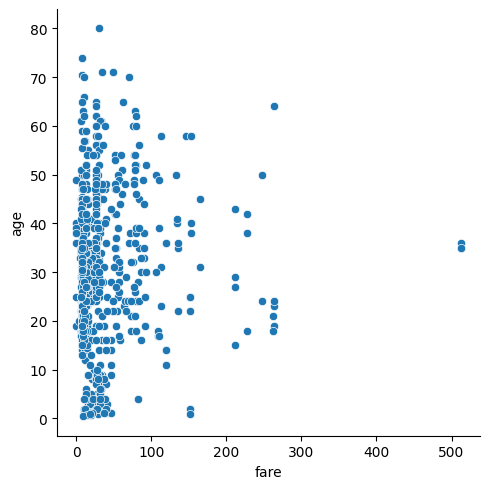

In [92]:
sns.relplot(
    data=df, 
    x='fare', 
    y='age',
    kind = 'scatter'
)

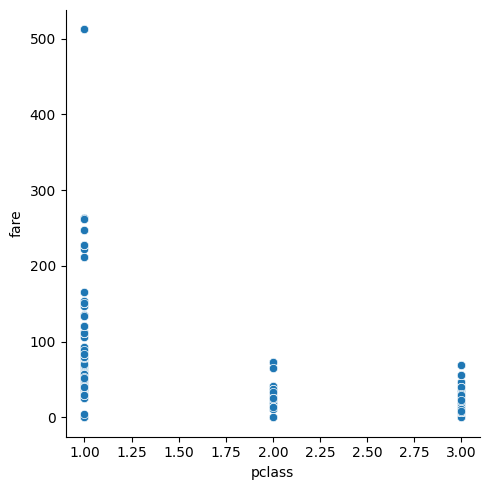

In [94]:
sns.relplot(
    data=df, 
    x='pclass', 
    y='fare',
    kind = 'scatter'
)

<Axes: >

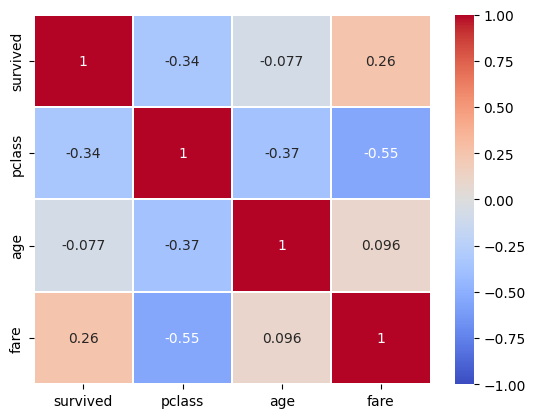

In [99]:
sns.heatmap(
    df.corr(),
    vmin=-1, vmax=1, annot = True,
    linewidths = 0.2, cmap = "coolwarm"
)
